In [18]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report

from utils import data_loader_utils
from utils import user_defined_functions as udf

from scipy import signal

import itertools
# Same as it shows in Decision_Tree.ipynb
DATA_ROOT = Path("./data")
OP = "OP07"
TRAIN_MACHINE = "M01"
TEST_MACHINES = ["M02", "M03"]

ORIGINAL_FS = 2000
TARGET_FS = 1000
WS = 4096   # the paper also indicates the same window length

In [19]:
def list_h5_files(machine, op, label):
    # label: "good" / "bad"
    folder = DATA_ROOT / machine / op / label
    return sorted(folder.glob("*.h5"))

def load_xyz(file_path):
    arr = data_loader_utils.datafile_read(file_path, False)
    return arr[:, :3]

# downsample to 1khz
def resample_xyz(xyz, fs_in=ORIGINAL_FS, fs_out=TARGET_FS):
    xs = udf.resample_milling_data(xyz[:,0], fs_in, fs_out)
    ys = udf.resample_milling_data(xyz[:,1], fs_in, fs_out)
    zs = udf.resample_milling_data(xyz[:,2], fs_in, fs_out)
    return np.stack([xs, ys, zs], axis=1)

# normalize every window (z-score)
def zscore_per_window(w, eps=1e-8):
    mu = w.mean(axis=0, keepdims=True)
    sd = w.std(axis=0, keepdims=True) + eps
    return (w - mu) / sd

def sliding_windows(xyz: np.ndarray, ws=WS):
    n = len(xyz)
    out = []
    for start in range(0, n - ws + 1, int(float(ws)/2)):
        out.append(xyz[start:start+ws])
    return out

In [20]:
WS  = 4096
HOP = WS // 2

def make_windows(x, ws=WS, hop=HOP):
    # x: (N,3)
    out = []
    for s in range(0, x.shape[0] - ws + 1, hop):
        out.append(x[s:s+ws])
    return out

def windows_for_group(machine, label, op="OP07"):
    files = list_h5_files(machine, op, label)
    windows = []
    for fp in files:
        xyz = load_xyz(fp)
        xyz = resample_xyz(xyz)             
        for w in make_windows(xyz):
            windows.append(zscore_per_window(w))
    return windows

groups = {}
for m in ["M01","M02","M03"]:
    for lab in ["good","bad"]:
        groups[(m, lab)] = windows_for_group(m, lab, op="OP07")

In [21]:
def acf_1d(x, max_lag=512):
    x = x.astype(np.float32, copy=False)
    x = x - x.mean()
    denom = (x @ x) + 1e-12
    r = np.correlate(x, x, mode="full")[len(x)-1:len(x)+max_lag]
    return r / denom  # normalized ACF (r[0] = 1)

def group_signature_acf(windows, axis_idx, max_lag=512):
    # average ACF across windows
    acc = np.zeros(max_lag + 1)
    for w in windows:
        acc += acf_1d(w[:, axis_idx], max_lag=max_lag)
    return acc / max(len(windows), 1)

In [22]:
AXES = ["X","Y","Z"]
MAX_LAG = 512

sign = {}  # sign[(machine,label,axis)]
for (m, lab), wins in groups.items():
    for a, ax in enumerate(AXES):
        sign[(m, lab, ax)] = group_signature_acf(wins, a, max_lag=MAX_LAG)


In [23]:
def corr_and_cov(vecA, vecB):
    corr = np.corrcoef(vecA, vecB)[0,1]
    cov  = np.cov(vecA, vecB, bias=False)[0,1]
    return corr, cov


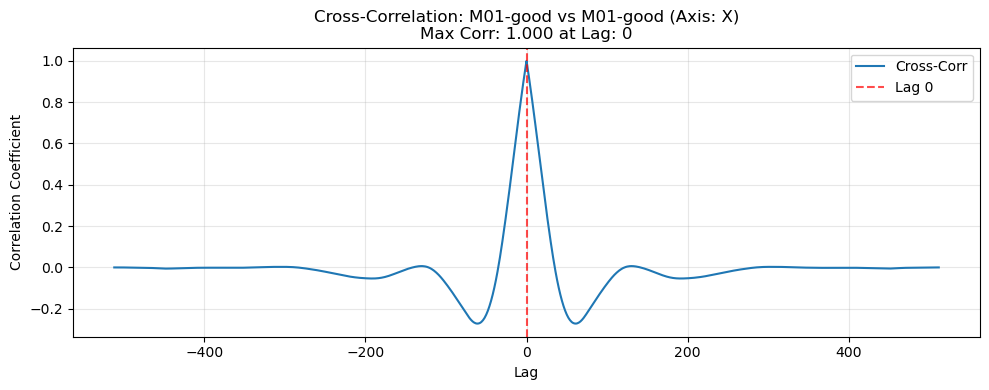

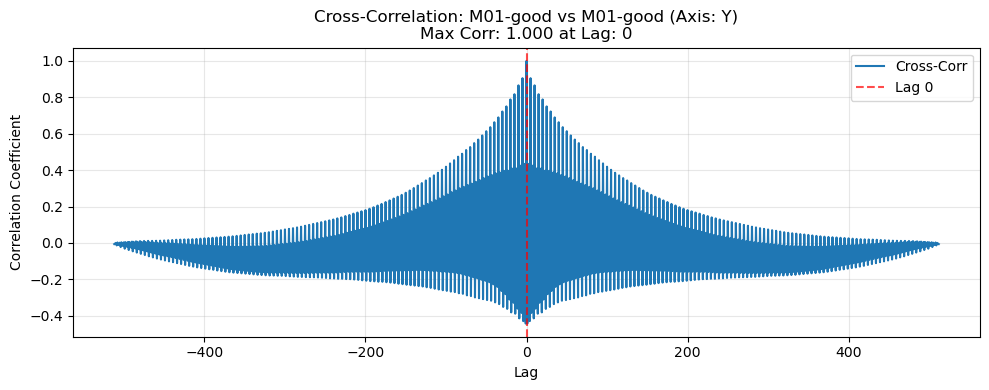

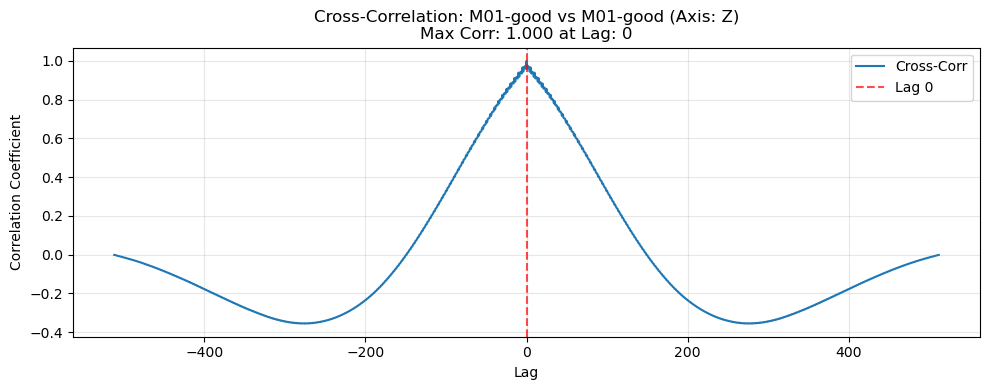

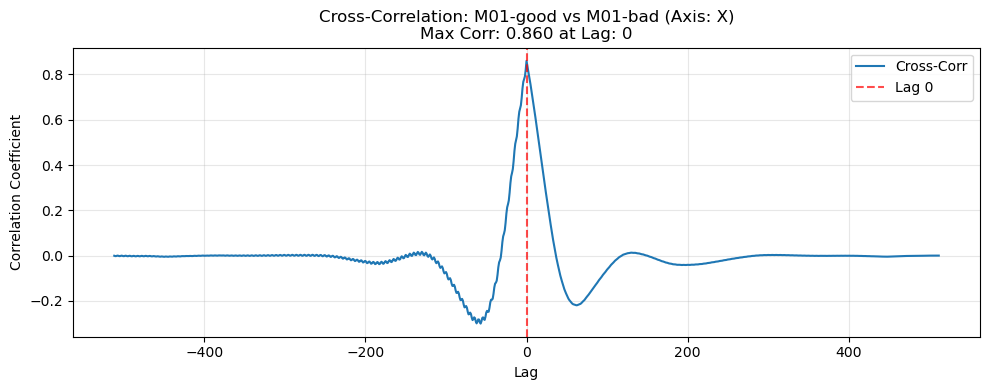

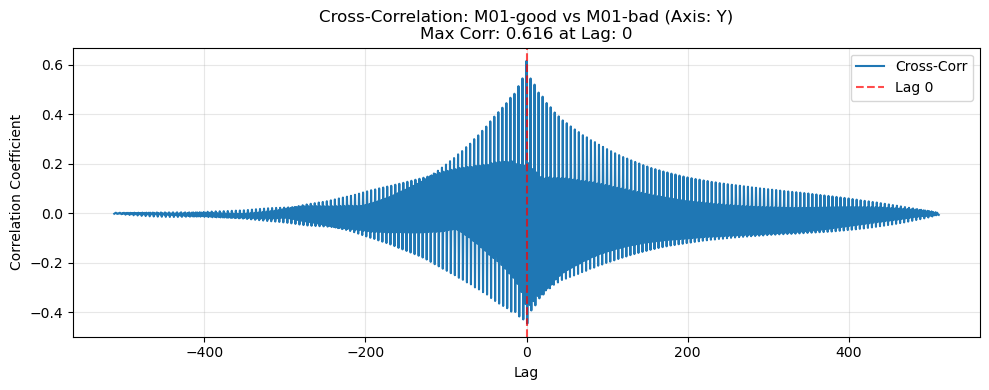

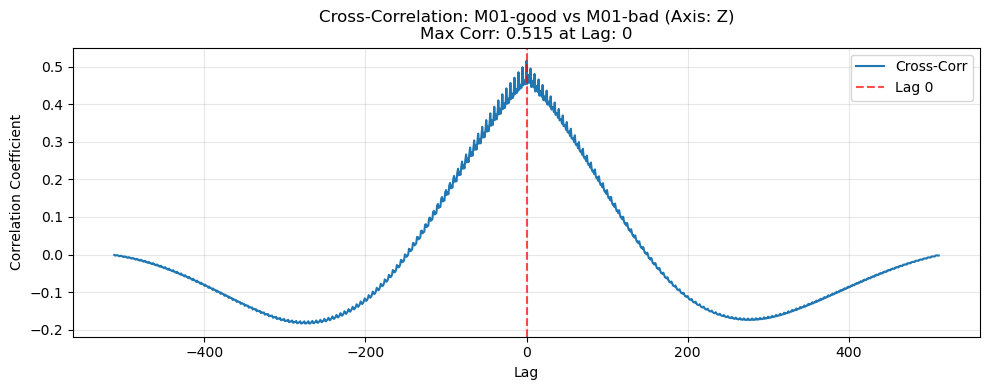

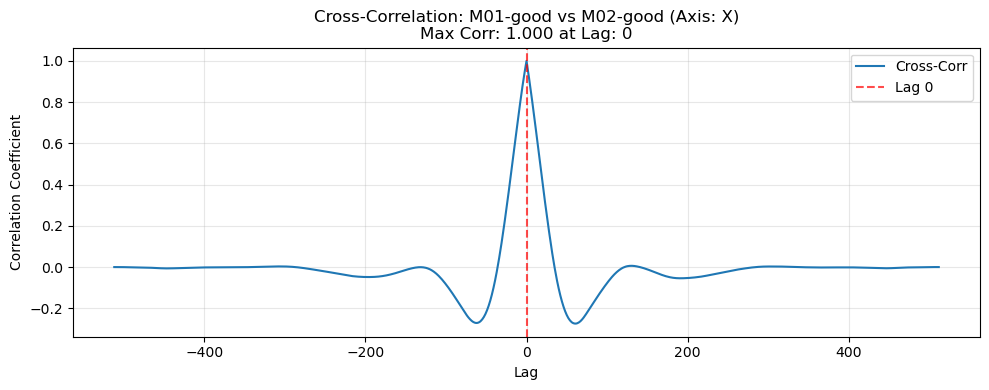

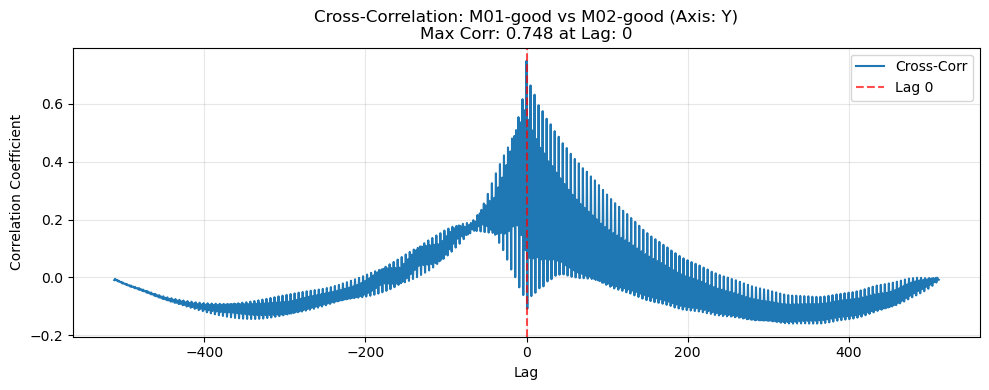

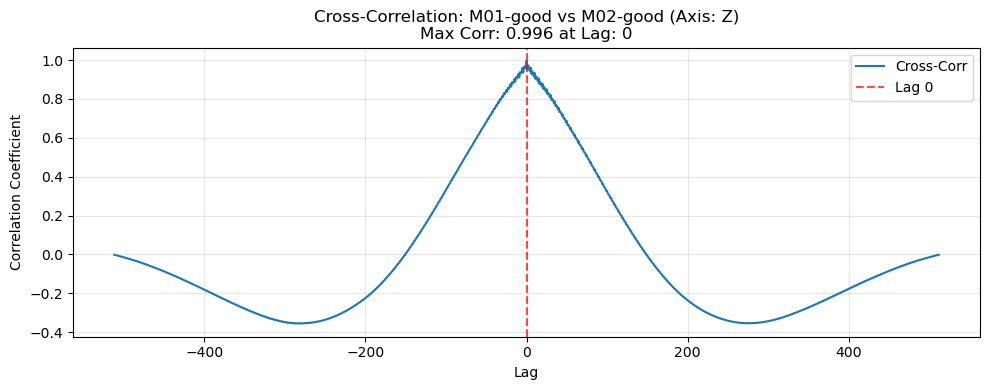

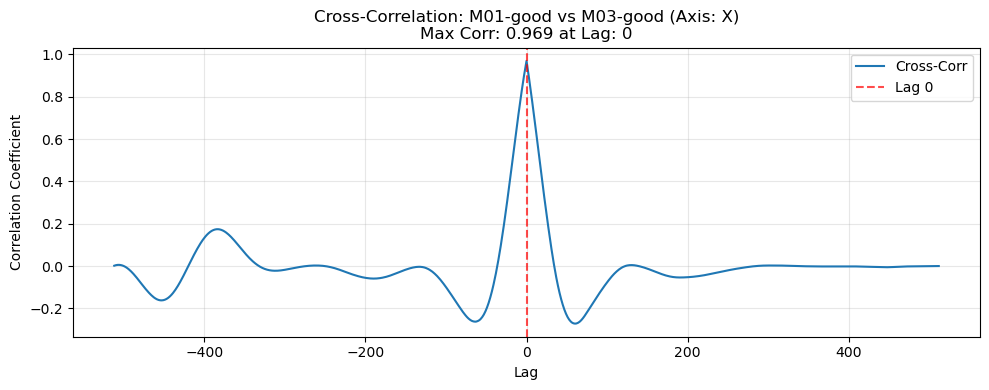

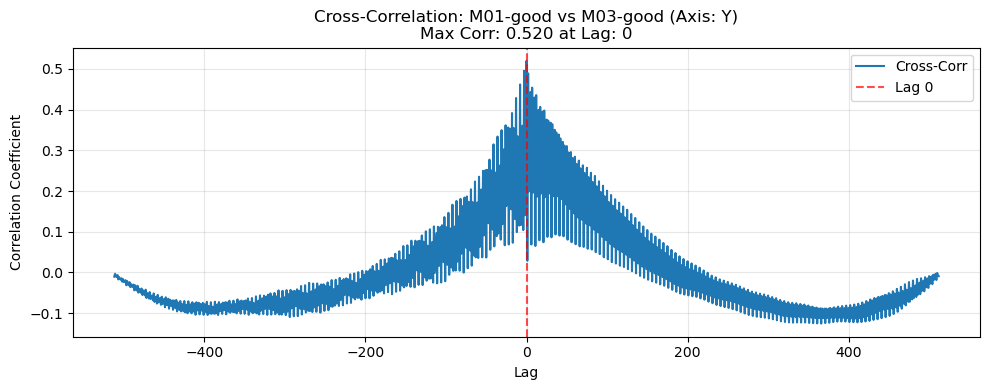

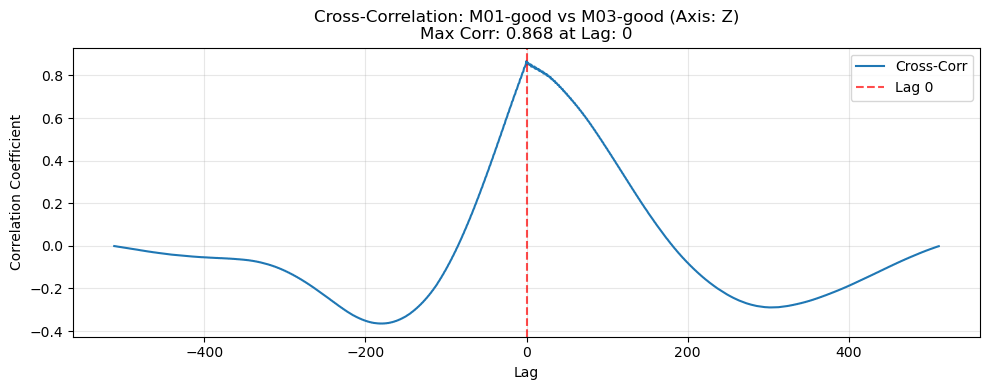

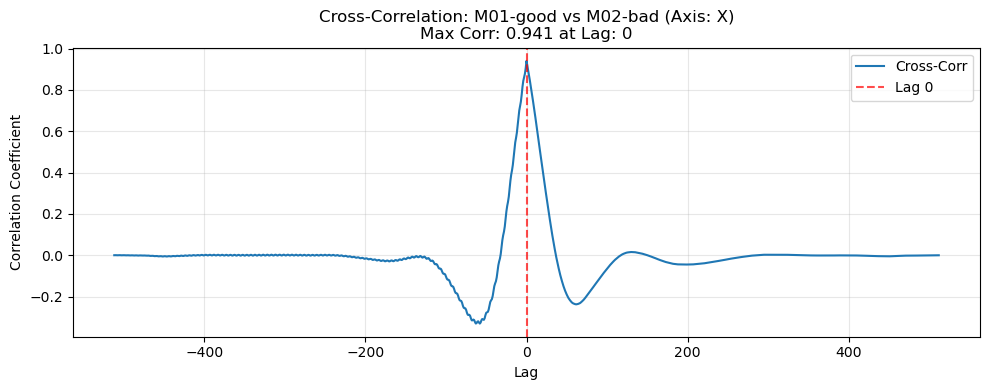

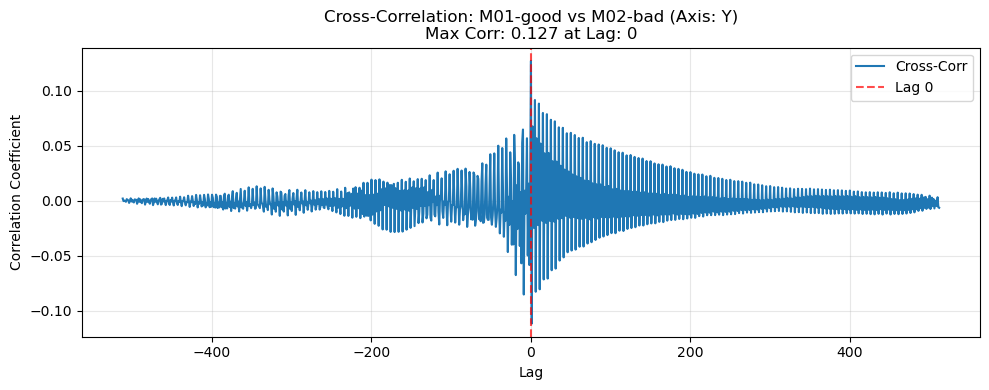

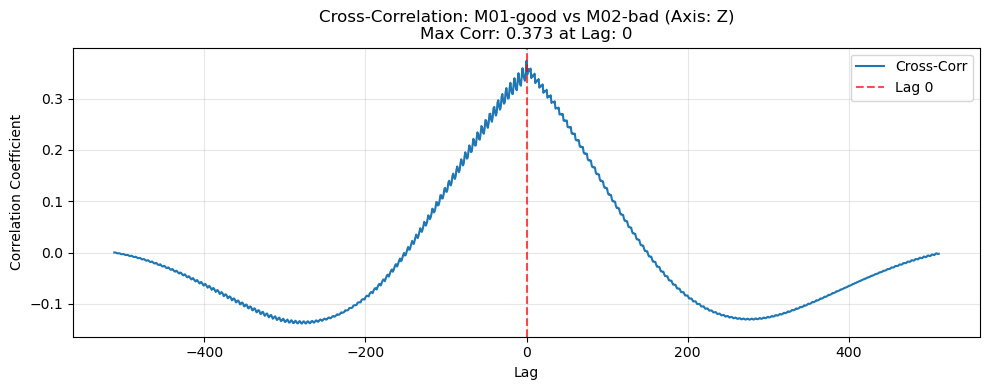

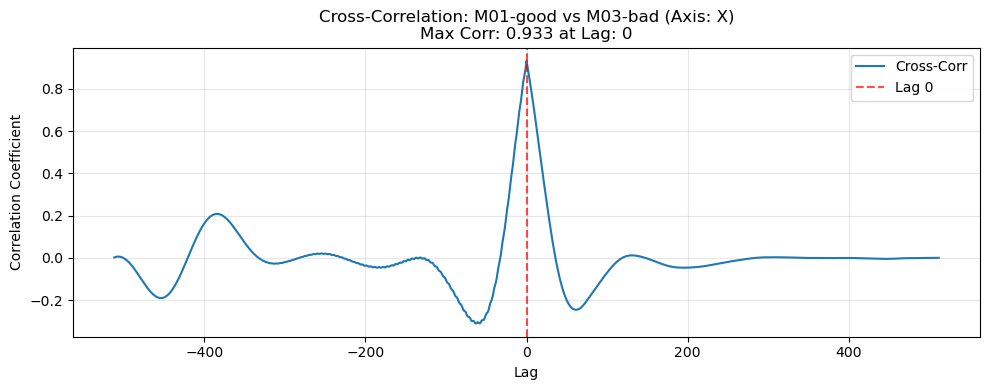

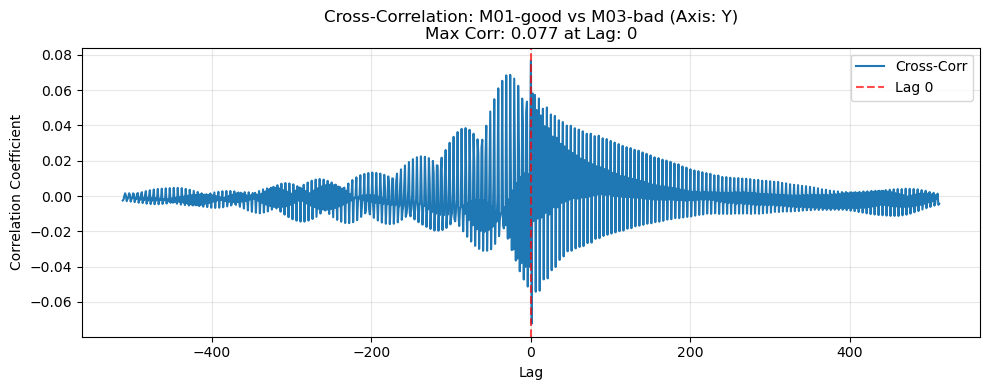

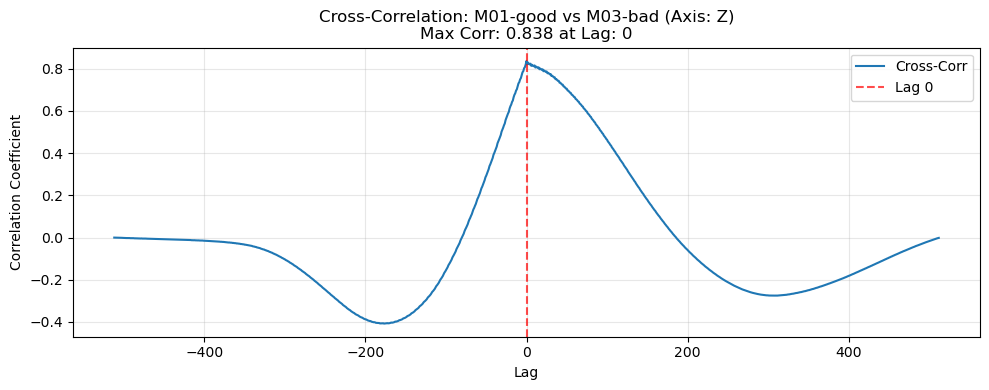

In [24]:
def plot_cross_correlation(vecA, vecB, labelA, labelB, axis_name):
    """
    Computes and plots the cross-correlation between two vectors (vecA, vecB).
    It normalizes the signals so the peak correlation is between -1 and 1.
    """
    # 1. Normalize vectors (Zero-mean, Unit-variance)
    #    This ensures the result is a "Correlation Coefficient" (-1 to 1)
    #    rather than just a raw dot product.
    vA = (vecA - np.mean(vecA))
    vA = vA / (np.std(vA) * len(vA)) # normalization factor
    vB = (vecB - np.mean(vecB))
    vB = vB / np.std(vB)
    
    # 2. Compute Cross-Correlation using FFT (fast for large arrays)
    xc = signal.correlate(vA, vB, mode='full')
    
    # 3. generate the lag axis
    lags = signal.correlation_lags(len(vecA), len(vecB), mode='full')
    
    # 4. Plot
    plt.figure(figsize=(10, 4))
    plt.plot(lags, xc, label='Cross-Corr')
    plt.axvline(0, color='red', linestyle='--', alpha=0.7, label='Lag 0')
    
    # Add scalar details for reference
    peak_corr = np.max(np.abs(xc))
    peak_lag = lags[np.argmax(np.abs(xc))]
    
    plt.title(f"Cross-Correlation: {labelA} vs {labelB} (Axis: {axis_name})\n"
              f"Max Corr: {peak_corr:.3f} at Lag: {peak_lag}")
    plt.xlabel("Lag")
    plt.ylabel("Correlation Coefficient")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # SAVE HERE
    plt.savefig(f'xcorr_{labelA}_{labelB}_{axis_name}.png', dpi=300, bbox_inches='tight')

    plt.show()

# --- Loop through your pairs and plot ---
pairs = [
    (("M01","good"), ("M01","good")),
    (("M01","good"), ("M01","bad")),
    (("M01","good"), ("M02","good")),
    (("M01","good"), ("M03","good")),
    (("M01","good"), ("M02","bad")),
    (("M01","good"), ("M03","bad")),
]

for (A, B) in pairs:
    for ax in AXES:
        vA = sign[(A[0], A[1], ax)]
        vB = sign[(B[0], B[1], ax)]
    
        label_A = f"{A[0]}-{A[1]}"
        label_B = f"{B[0]}-{B[1]}"

        plot_cross_correlation(vA, vB, label_A, label_B, ax)


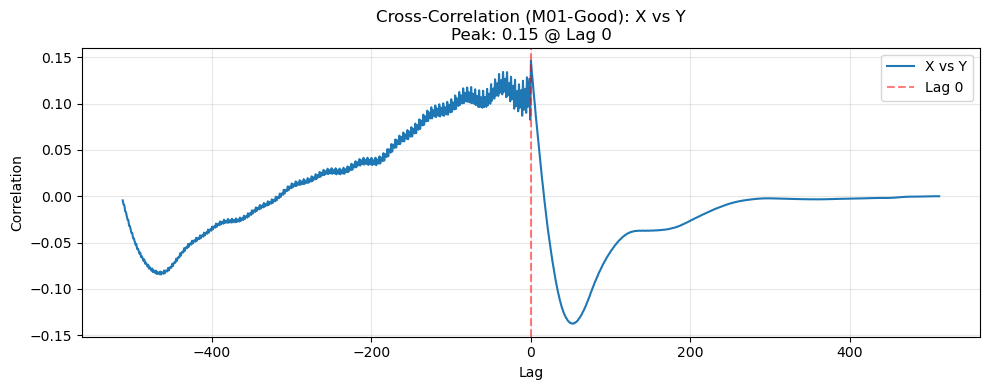

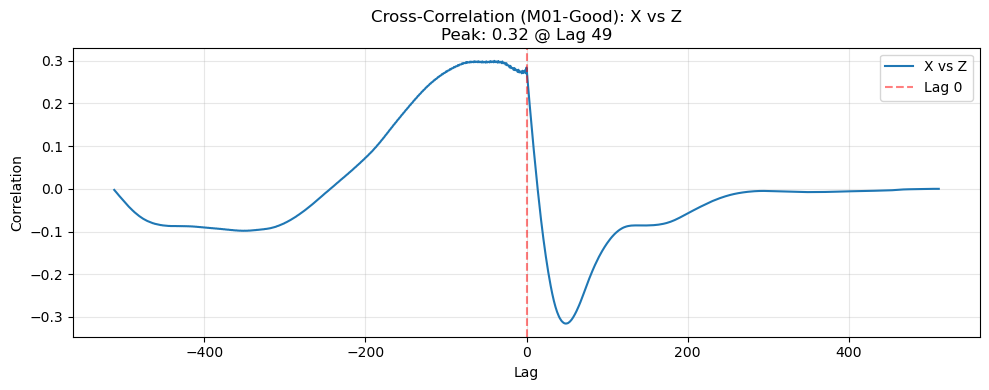

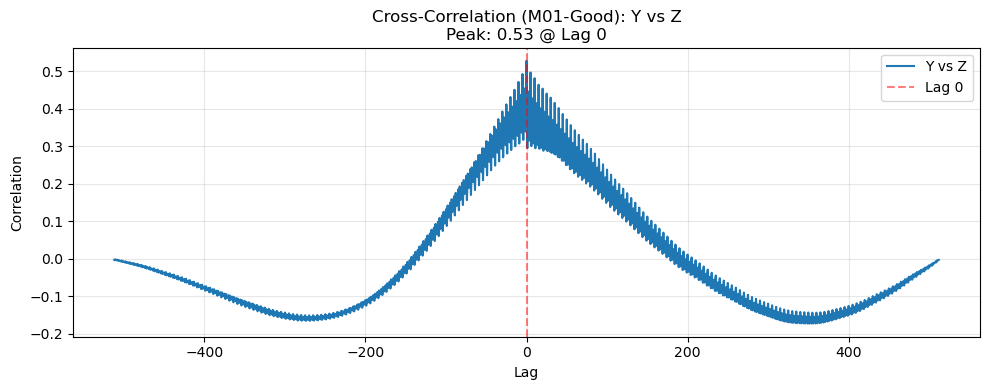

In [25]:
# Define the function (same as before)
def plot_cross_correlation(vecA, vecB, labelA, labelB):
    vA = (vecA - np.mean(vecA))
    vA = vA / (np.std(vA) * len(vA))
    vB = (vecB - np.mean(vecB))
    vB = vB / np.std(vB)
    
    xc = signal.correlate(vA, vB, mode='full')
    lags = signal.correlation_lags(len(vecA), len(vecB), mode='full')
    
    peak_val = np.max(np.abs(xc))
    peak_lag = lags[np.argmax(np.abs(xc))]
    
    plt.figure(figsize=(10, 4))
    plt.plot(lags, xc, label=f'{labelA} vs {labelB}')
    plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Lag 0')
    plt.title(f"Cross-Correlation (M01-Good): {labelA} vs {labelB}\nPeak: {peak_val:.2f} @ Lag {peak_lag}")
    plt.xlabel("Lag")
    plt.ylabel("Correlation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save unique filename
    plt.savefig(f'xcorr_M01_good_{labelA}_vs_{labelB}.png', dpi=300)
    plt.show()

for ax1, ax2 in itertools.combinations(AXES, 2):
    
    # Fetch data for M01-good
    vecA = sign[("M01", "good", ax1)]
    vecB = sign[("M01", "good", ax2)]
    
    plot_cross_correlation(vecA, vecB, ax1, ax2)

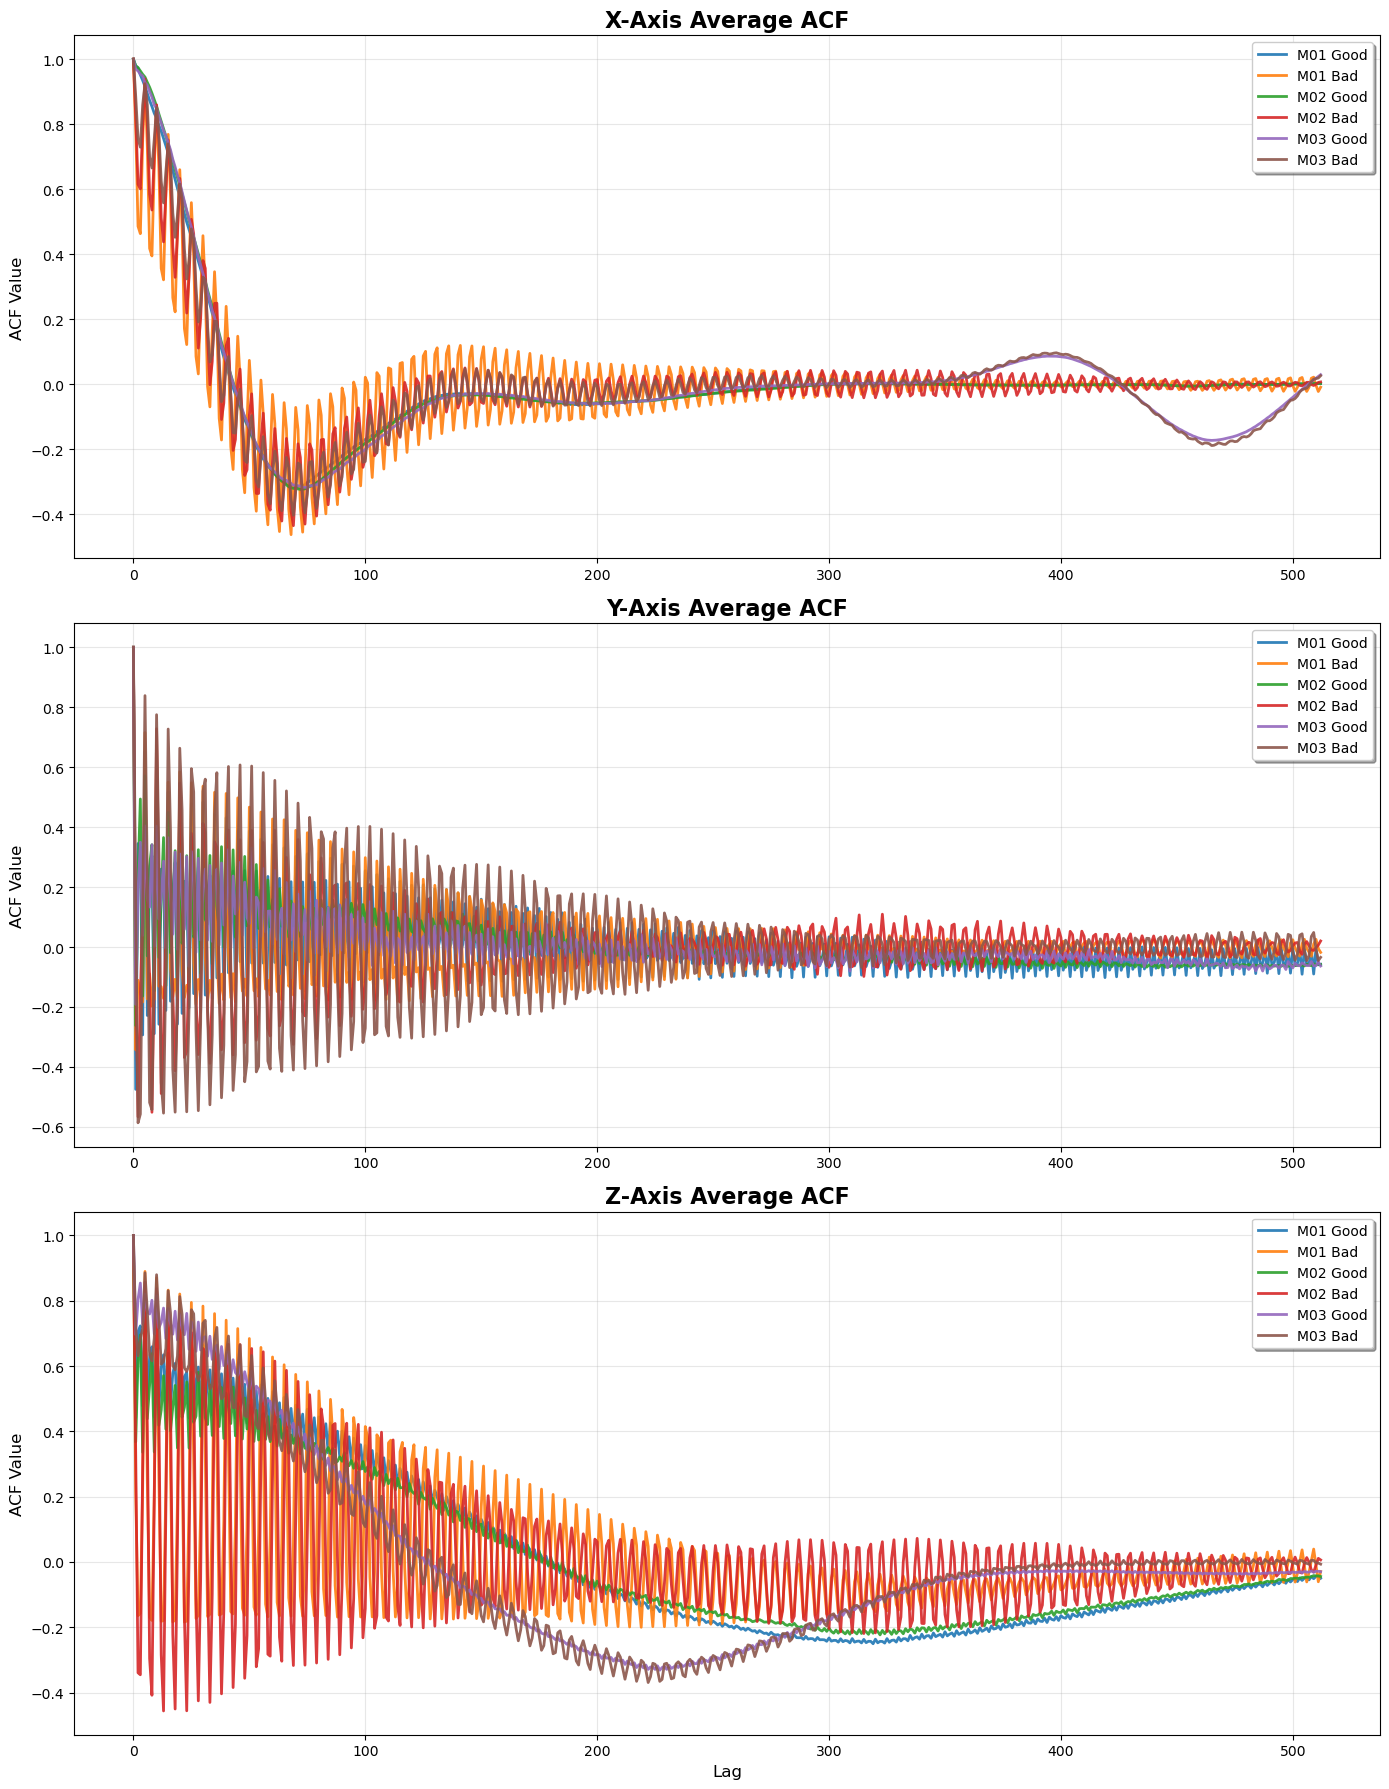

In [30]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_acfs_distinct_colors(sign_data, machines=["M01", "M02", "M03"], axes=["X", "Y", "Z"]):
    """
    Plots 3 figures (one per Axis).
    Every Machine-Condition pair has a unique color.
    """
    
    # Define distinct colors for the 6 combinations
    # You can customize these hex codes if needed
    color_map = {
        ("M01", "good"): "#1f77b4", # Blue
        ("M01", "bad"):  "#ff7f0e", # Orange
        ("M02", "good"): "#2ca02c", # Green
        ("M02", "bad"):  "#d62728", # Red
        ("M03", "good"): "#9467bd", # Purple
        ("M03", "bad"):  "#8c564b", # Brown
    }

    fig, axs = plt.subplots(3, 1, figsize=(14, 18)) # Taller figure for clarity

    for i, ax_name in enumerate(axes):
        ax = axs[i]
        
        for mach in machines:
            for lbl in ["good", "bad"]:
                key = (mach, lbl, ax_name)
                
                if key in sign_data:
                    # Create a clear legend label
                    label_str = f"{mach} {lbl.capitalize()}"
                    
                    # Get the assigned color
                    color = color_map.get((mach, lbl), "black")
                    
                    ax.plot(
                        sign_data[key], 
                        label=label_str, 
                        color=color, 
                        linewidth=2,   # Thicker lines for visibility
                        alpha=0.9
                    )

        ax.set_title(f"{ax_name}-Axis Average ACF", fontsize=16, fontweight='bold')
        ax.set_ylabel("ACF Value", fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Place legend outside or in a clear spot
        ax.legend(loc="upper right", fontsize='medium', frameon=True, shadow=True)

    axs[-1].set_xlabel("Lag", fontsize=12)
    plt.tight_layout()
    plt.savefig('acf_comparison.png', dpi=300)
    plt.show()

# Run the plotting function
plot_acfs_distinct_colors(sign)